<a href="https://colab.research.google.com/github/withfablue/PyTorch/blob/main/Chapter6_Generative_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DCGAN

In [1]:
# 1. Dataloader
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),                # (H, W, C) -> (C, H, W), 값 범위 [0, 1]
    transforms.Normalize((0.5,), (0.5,))  # [0,1] -> [-1, 1] 로 정규화
])

dataset = datasets.MNIST(
    root='data',
    train=True,
    transform=transform,
    download=True
)

loader = DataLoader(dataset, batch_size=64, shuffle=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.98MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 126kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.19MB/s]


In [2]:
# 2. Generator network
import torch.nn as nn

class Generator(nn.Module):
  def __init__(self, latent_dim=64):
    super().__init__()
    self.model = nn.Sequential(
        # 입력: (B, latent_dim, 1, 1)
        nn.ConvTranspose2d(latent_dim, 128, kernel_size=7, stride=1, padding=0),  # -> (B, 128, 7, 7)
        nn.BatchNorm2d(128),
        nn.ReLU(),

        nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # -> (B, 64, 14, 14)
        nn.BatchNorm2d(64),
        nn.ReLU(),

        nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),   # -> (B, 1, 28, 28)
        nn.Tanh()
    )

  def forward(self, z):
    return self.model(z)

generator = Generator()

In [3]:
# 3. DIscriminator network
class Discriminator(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(
        # 입력: (B, 1, 28, 28)
        nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1), # -> (B, 64, 14, 14),
        nn.LeakyReLU(),

        nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # -> (B, 128, 7, 7)
        nn.BatchNorm2d(128),
        nn.LeakyReLU(),

        nn.Flatten(),  # -> (B, 128*7*7)
        nn.Linear(128*7*7, 1),
        nn.Sigmoid()
    )

  def forward(self, x):
    return self.model(x)

discriminator = Discriminator()

In [4]:
# 4. Loss function & optimizer

criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(
    generator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

optimizer_D = torch.optim.Adam(
    discriminator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

latent_dim=64

In [8]:
# 5. Training loop
num_epochs=10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator.to(device)
discriminator.to(device)

for epoch in range(num_epochs):
  for real_imgs, _ in loader:
    real_imgs = real_imgs.to(device)  # (B, 1, 28, 28)
    batch_size = real_imgs.size(0)

    # 1. Discriminator training
    optimizer_D.zero_grad()

    # 진짜 이미지에 대한 판별 결과와 손실
    real_labels = torch.ones(batch_size, 1).to(device)
    fake_labels = torch.zeros(batch_size, 1).to(device)
    d_real = discriminator(real_imgs)
    loss_real = criterion(d_real, real_labels)

    # 생성된 가짜 이미지에 대한 판별 결과와 손실
    z = torch.randn(batch_size, latent_dim, 1, 1).to(device)
    fake_imgs = generator(z)
    d_fake = discriminator(fake_imgs.detach())
    loss_fake = criterion(d_fake, fake_labels)

    loss_D = loss_real + loss_fake
    loss_D.backward()
    optimizer_D.step()

    # 2. Generator training
    optimizer_G.zero_grad()

    d_fake = discriminator(fake_imgs)
    loss_G = criterion(d_fake, real_labels)
    loss_G.backward()
    optimizer_G.step()

  print(f"Epoch {epoch+1}, D={loss_D.item():.4f}, G={loss_G.item():.4f}")


Epoch 1, D=0.5891, G=2.6903
Epoch 2, D=0.4637, G=2.6626
Epoch 3, D=0.6296, G=1.0807
Epoch 4, D=0.6467, G=1.9920
Epoch 5, D=0.4009, G=2.0888
Epoch 6, D=0.1951, G=3.4546
Epoch 7, D=0.6033, G=1.9130
Epoch 8, D=0.4944, G=1.4606
Epoch 9, D=0.4248, G=2.9574
Epoch 10, D=0.5291, G=1.4979


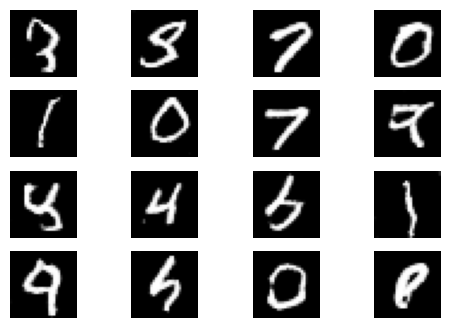

In [12]:
# 6. Visualization
import matplotlib.pyplot as plt

generator.eval()
with torch.no_grad():
  z = torch.randn(16, latent_dim, 1, 1).to(device)
  samples = generator(z).cpu()

plt.figure(figsize=(6,4))
for i in range(16):
  plt.subplot(4, 4, i+1)
  plt.imshow(samples[i].squeeze(), cmap='gray')
  plt.axis("off")
plt.show()